In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ID_66.csv', sep=';')
df['date'] = pd.to_datetime(df[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn = (df['date'] >= '1993-10-01') & (df['date'] <= '2023-09-30')
df_30ar = df.loc[gogn].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

4.1 Árstíðarsveifla

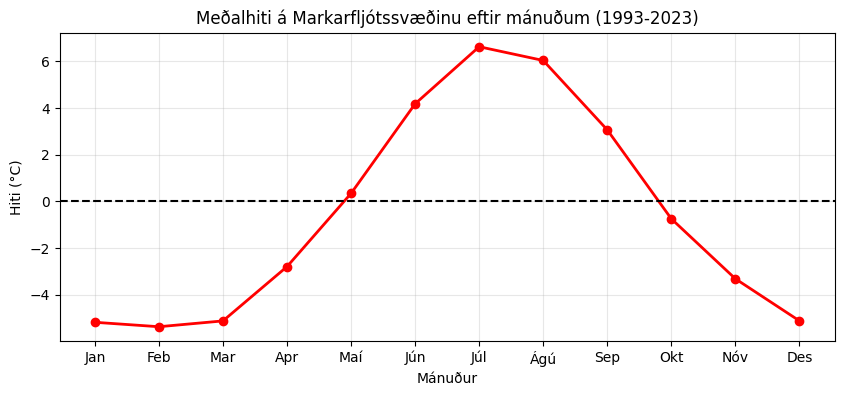

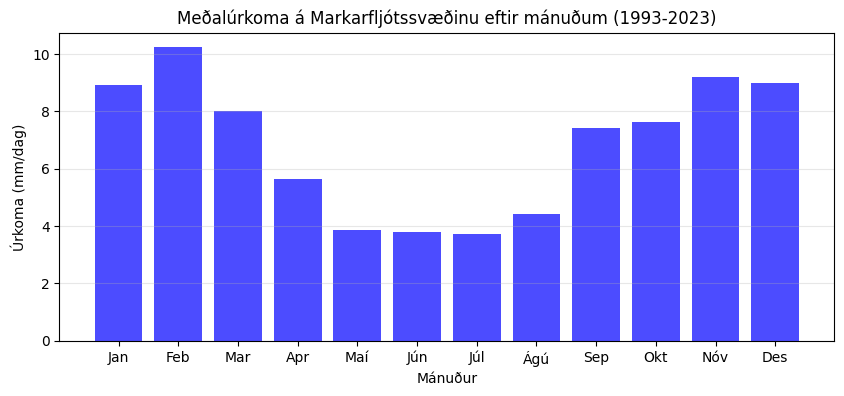

In [3]:
# Graf 1 - Hitastig
plt.figure(figsize=(10, 4))
plt.plot(manudir, medaltalsar_manudir['2m_temp_carra'], color='red', marker='o', linewidth=2)
plt.axhline(0, color='black', linestyle='--') # Frostmarkslína
plt.title('Meðalhiti á Markarfljótssvæðinu eftir mánuðum (1993-2023)')
plt.xlabel('Mánuður')
plt.ylabel('Hiti (°C)')
plt.xticks(manudir, manudir_nofn)
plt.grid(True, alpha=0.3)
plt.show()

# Graf 2 - Úrkoma
plt.figure(figsize=(10, 4))
plt.bar(manudir, medaltalsar_manudir['prec_carra'], color='blue', alpha=0.7)
plt.title('Meðalúrkoma á Markarfljótssvæðinu eftir mánuðum (1993-2023)')
plt.xlabel('Mánuður')
plt.ylabel('Úrkoma (mm/dag)')
plt.xticks(manudir, manudir_nofn)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [4]:
import pandas as pd

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

df_q['date'] = pd.to_datetime(df_q[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn_1 = (df_q['date'] >= '1993-10-01') & (df_q['date'] <= '2023-09-30')
df_30ar = df_q.loc[gogn_1].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

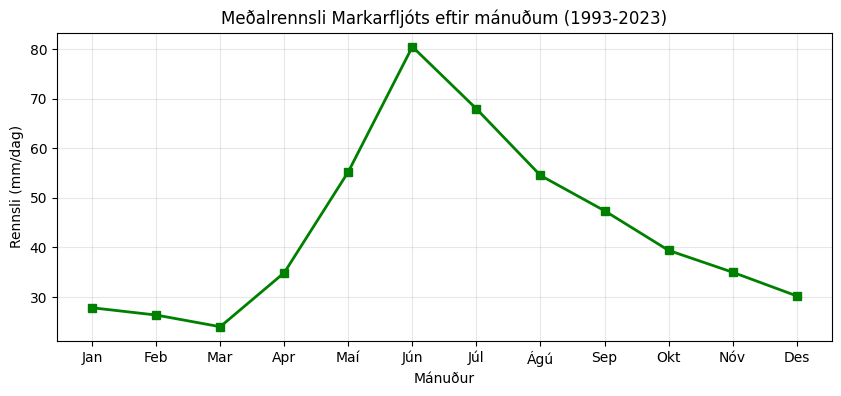

In [5]:
# Graf 3 - Rennsli
plt.figure(figsize=(10, 4))
plt.plot(manudir, medaltalsar_manudir['qobs'], color='green', marker='s', linewidth=2)
plt.title('Meðalrennsli Markarfljóts eftir mánuðum (1993-2023)')
plt.xlabel('Mánuður')
plt.ylabel('Rennsli (mm/dag)')
plt.xticks(manudir, manudir_nofn)
plt.grid(True, alpha=0.3)
plt.show()

4.2 Mat á grunnvatnsframlagi

In [6]:
import pandas as pd

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

df_q['date'] = pd.to_datetime(df_q[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# 3. Sía gögnin fyrir tímabilið 1993-2023
gogn_1 = (df_q['date'] >= '1993-10-01') & (df_q['date'] <= '2023-09-30')
df_q_30ar = df_q.loc[gogn_1].copy()

print(df_q.columns.tolist())

['YYYY', 'MM', 'DD', 'qobs', 'qc_flag', 'date']


In [7]:

# Síustuðull
alpha = 0.925

# Búa til tóma dálka yfir yfirborðsrennnsli(yr) og grunnvatnsrennsli(gr) og fyllum svo inn í með for-lykkju
df_q_30ar['yr'] = 0.0  
df_q_30ar['gr'] = 0.0  

yr = 0 # upphafspunktur fyrir yfirborðsrennsli
for i in range(1, len(df_q_30ar)):
    # Notum qobs sem er mælt rennsli
    rennsli_i_dag = df_q_30ar['qobs'].iloc[i]
    rennsli_i_gaer = df_q_30ar['qobs'].iloc[i-1]
    
    yr = alpha * yr + ((1 + alpha) / 2) * (rennsli_i_dag - rennsli_i_gaer)
    
    # Passa að tölurnar séu raunhæfar (rennsli ekki undir 0 og að yr sé ekki hærri en heildarrennslið)
    yr = max(0, min(yr, rennsli_i_dag))
    
    df_q_30ar.iloc[i, df_q_30ar.columns.get_loc('yr')] = yr
    df_q_30ar.iloc[i, df_q_30ar.columns.get_loc('gr')] = rennsli_i_dag - yr

# 3. Reikna BFI 
heildar_rennsli = df_q_30ar['qobs'].sum()
heildar_gr = df_q_30ar['gr'].sum()
bfi = heildar_gr / heildar_rennsli

print(f'Heildarrennsli yfir tímabilið er: {round(heildar_rennsli,3)}')

print(f'Heildar grunnrennsli yfir tímabilið er: {round(heildar_gr,3)}')

print(f"Baseflow Index (BFI) fyrir Markarfljót er: {round(bfi, 3)}")

Heildarrennsli yfir tímabilið er: 478565.7
Heildar grunnrennsli yfir tímabilið er: 384967.378
Baseflow Index (BFI) fyrir Markarfljót er: 0.804


In [ ]:
# Recession analysis og recession constant
# Skoðum þá daga þar sem rennslið er að lækka (recession)
recession_dagar = df_q_30ar[df_q_30ar['qobs'] < df_q_30ar['qobs'].shift(1)]

# Recession constant k er hlutfallið á milli dagsins í dag og gærdagsins
k_gildi = recession_dagar['qobs'] / recession_dagar['qobs'].shift(1)
k_fasti = k_gildi.median()

print(f"Recession constant (k) er: {round(k_fasti, 3)}")

Recession constant (k) er: 0.97


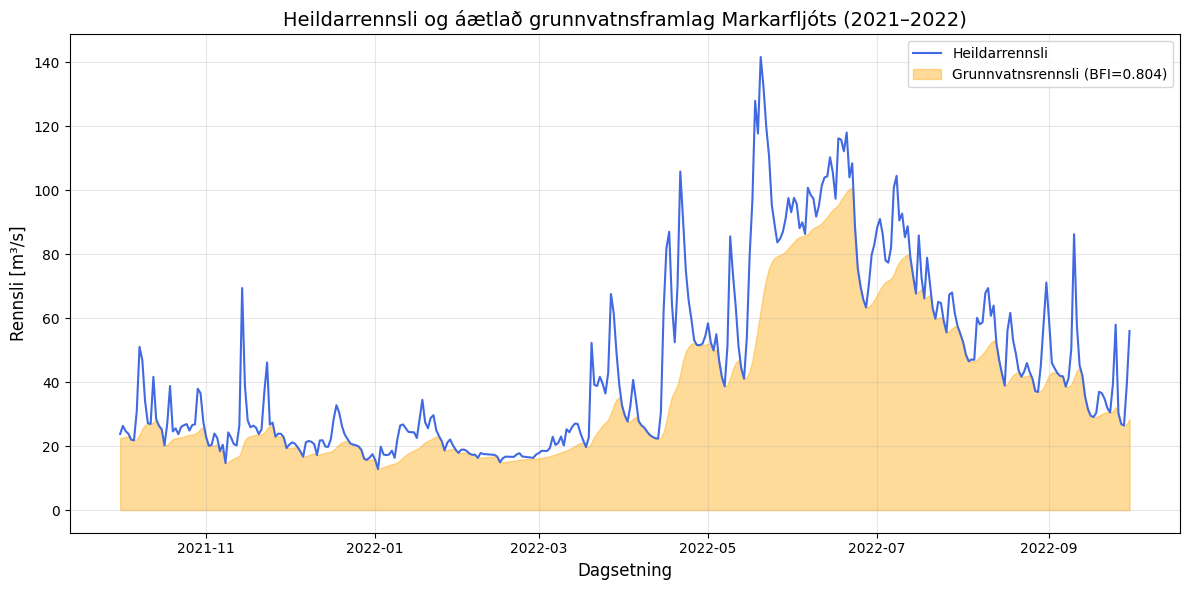

In [9]:
import matplotlib.pyplot as plt

# 1. Veljum eitt gott ár til að sýna (t.d. 2021)
dæmi = df_q_30ar[(df_q_30ar['date'] >= '2021-10-01') & (df_q_30ar['date'] <= '2022-09-30')]

plt.figure(figsize=(12, 6))

# Teikna heildarrennslið
plt.plot(dæmi['date'], dæmi['qobs'], label='Heildarrennsli', color='royalblue', linewidth=1.5)

# Setja inn grunnvatnrennslið og fylla fyrir neðan
plt.fill_between(dæmi['date'], dæmi['gr'], color='orange', alpha=0.4, label=f'Grunnvatnsrennsli (BFI=0.804)')

plt.title('Heildarrennsli og áætlað grunnvatnsframlag Markarfljóts (2021–2022)', fontsize=14)
plt.xlabel('Dagsetning', fontsize=12)
plt.ylabel('Rennsli [m³/s]', fontsize=12) # Athugaðu einingarnar þínar
plt.grid(alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

4.3 Tenging við grunnlíkingu

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ID_66.csv', sep=';')
df['date'] = pd.to_datetime(df[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn = (df['date'] >= '1993-10-01') & (df['date'] <= '2023-09-30')
df_30ar = df.loc[gogn].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

In [13]:
import pandas as pd

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

df_q['date'] = pd.to_datetime(df_q[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn_1 = (df_q['date'] >= '1993-10-01') & (df_q['date'] <= '2023-09-30')
df_30ar_1 = df_q.loc[gogn_1].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir_1 = df_30ar_1.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

In [17]:
# Listi yfir fjölda daga í hverjum mánuði (janúar - desember)
dagar_i_manudi = [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# Reikna ársmeðaltöl fyrir P, Q og E
P_ar = (medaltalsar_manudir['prec_carra']*dagar_i_manudi).sum()
Q_ar = (medaltalsar_manudir_1['qobs']*dagar_i_manudi).sum()
E_ar = (medaltalsar_manudir['total_et']*dagar_i_manudi).sum()

print(f"Meðalúrkoma (P): {round(P_ar, 1)} mm/ári")
print(f"Meðalrennsli (Q): {round(Q_ar, 1)} mm/ári")
print(f"Meðaluppgufun (E): {round(E_ar, 1)} mm/ári")

# Reikna geymsluna delta S 
mismunur = P_ar - Q_ar - E_ar
print(f"Delta S: {round(mismunur, 1)} mm/ári")

Meðalúrkoma (P): 2483.3 mm/ári
Meðalrennsli (Q): 15952.6 mm/ári
Meðaluppgufun (E): 132.0 mm/ári
Delta S: -13601.3 mm/ári


4.4 Langæislína rennslis

4.5 Flóðagreining

4.6 Leitnigreining

4.7 Greining á rennslisatburði